# **Mental Health Detection using NLP**

**Problem Statement:** Detect the mental health status of a person from text statements.

**Dataset:** 53,043 rows | Columns: `Unnamed:0`, `statement`, `status`

## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [ ]:
df = pd.read_csv('/content/Combined Data.csv')
print('Shape:', df.shape)
df.head()

Shape: (53043, 3)


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


## 3. Understand Dataset

In [ ]:
# FIX: display each output separately — in one cell, only the last expression auto-displays
print('Shape:', df.shape)
print()
df.info()

Shape: (53043, 3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [ ]:
df.describe(include='all')

,Unnamed: 0,statement,status
count,53043.000000,52681,53043
unique,NaN,51073,7
top,NaN,what do you mean?,Normal
freq,NaN,22,16351
mean,26521.000000,NaN,NaN
std,15312.339501,NaN,NaN
min,0.000000,NaN,NaN
25%,13260.500000,NaN,NaN
50%,26521.000000,NaN,NaN
75%,39781.500000,NaN,NaN


In [ ]:
print('Null values:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())

Null values:
Unnamed: 0      0
statement     362
status          0
dtype: int64

Duplicate rows: 0


In [ ]:
print('Unique values per column:')
print(df.nunique())
print()
print('Status categories:', df['status'].unique())

Unique values per column:
Unnamed: 0    53043
statement     51073
status            7
dtype: int64

Status categories: ['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']


## 4. Data Cleaning

In [ ]:
# Drop unnamed index column, remove nulls, reset index
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df = df.dropna(subset=['statement', 'status'])
df = df.drop_duplicates()
df.index = range(len(df))
print('Clean dataset shape:', df.shape)

Clean dataset shape: (51093, 2)


## 5. Text Preprocessing

In [ ]:
import re
import string
import nltk

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# -------------------------------------------------------------------
# FIX #2: Contraction expansion dictionary
# Expand BEFORE removing punctuation so apostrophes don't get stripped
# -------------------------------------------------------------------
CONTRACTIONS = {
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "you're": "you are", "you've": "you have", "you'll": "you will", "you'd": "you would",
    "he's": "he is", "he'll": "he will", "he'd": "he would",
    "she's": "she is", "she'll": "she will", "she'd": "she would",
    "it's": "it is", "it'll": "it will",
    "we're": "we are", "we've": "we have", "we'll": "we will", "we'd": "we would",
    "they're": "they are", "they've": "they have", "they'll": "they will", "they'd": "they would",
    # --- CRITICAL NEGATIONS (expand so 'not' survives) ---
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "can't": "can not", "cannot": "can not", "couldn't": "could not",
    "won't": "will not", "wouldn't": "would not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "shouldn't": "should not", "mustn't": "must not", "mightn't": "might not",
    "needn't": "need not", "daren't": "dare not", "shan't": "shall not",
    "that's": "that is", "there's": "there is", "what's": "what is",
    "who's": "who is", "how's": "how is",
}

def expand_contractions(text):
    """Expand contractions so negations survive stopword removal."""
    for contraction, expansion in CONTRACTIONS.items():
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', expansion, text)
    return text

# -------------------------------------------------------------------
# FIX #1: Remove negation words from the stopword list
# These words are semantically critical for mental health text
# -------------------------------------------------------------------
NEGATION_WORDS = {
    'not', 'no', 'never', 'neither', 'nor', 'nothing',
    'nobody', 'nowhere', 'without', 'hardly', 'barely', 'scarcely'
}

stop_words = set(stopwords.words('english')) - NEGATION_WORDS
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    """Full preprocessing pipeline with negation preservation."""
    text = str(text).lower()
    text = text.encode('ascii', 'ignore').decode()          # remove non-ascii
    text = expand_contractions(text)                         # FIX #2: expand contractions first
    text = re.sub(r'http\S+|www\S+', '', text)             # remove URLs
    text = re.sub(r'<.*?>', '', text)                       # remove HTML tags
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)            # reduce repeated chars
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\d+', '', text)                        # remove digits
    text = re.sub(r'\s+', ' ', text).strip()               # normalize whitespace
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2 and w.isalpha()]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

# Quick sanity check — negation must survive
tests = [
    ("I do not feel hopeless",   "not" ),   # should contain 'not'
    ("I can not sleep at night", "not" ),   # should contain 'not'
    ("I never want to be here",  "never"),  # should contain 'never'
]
print('=== Negation Preservation Check ===')
all_pass = True
for text, word in tests:
    result = preprocess(text)
    ok = word in result.split()
    status = '✅ PASS' if ok else '❌ FAIL'
    print(f'{status}  "{text}"  →  "{result}"')
    if not ok:
        all_pass = False
print('All checks passed!' if all_pass else 'WARNING: Some checks failed!')

df['clean_text'] = df['statement'].apply(preprocess)
df['tokens']     = df['clean_text'].apply(lambda x: x.split())
print('\nPreprocessing done.')
df[['statement', 'clean_text']].head(3)

=== Negation Preservation Check ===
✅ PASS  "I do not feel hopeless"  →  "not feel hopeless"
✅ PASS  "I can not sleep at night"  →  "not sleep night"
✅ PASS  "I never want to be here"  →  "never want"
All checks passed!

Preprocessing done.


,statement,clean_text
0,oh my gosh,gosh
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",wrong back dear forward doubt stay restless re...


## 6. Data Visualization

### 6.1 Class Distribution

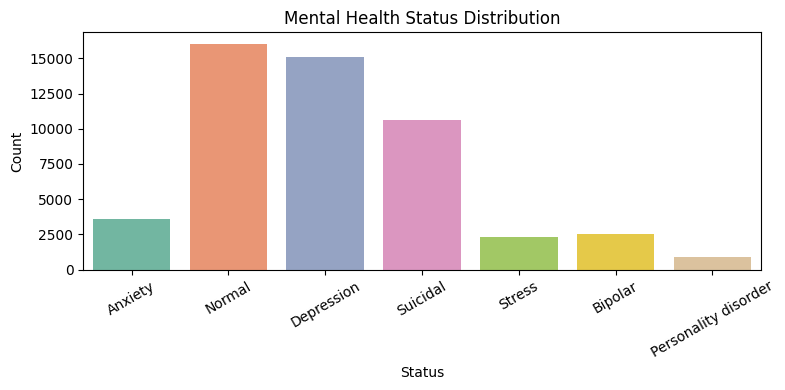

In [ ]:
plt.figure(figsize=(8, 4))
sns.countplot(x='status', data=df, palette='Set2')
plt.title('Mental Health Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 6.2 Word Cloud

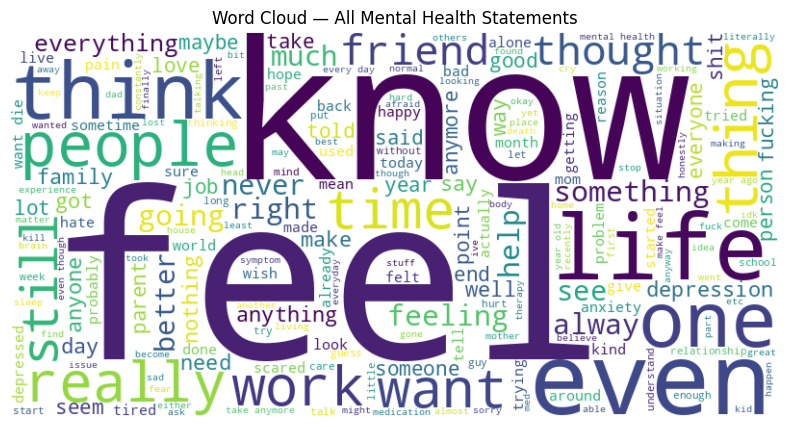

In [ ]:
!pip install wordcloud --quiet

from wordcloud import WordCloud

all_text = ' '.join(df['clean_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — All Mental Health Statements')
plt.show()

### 6.3 Top Word Frequencies

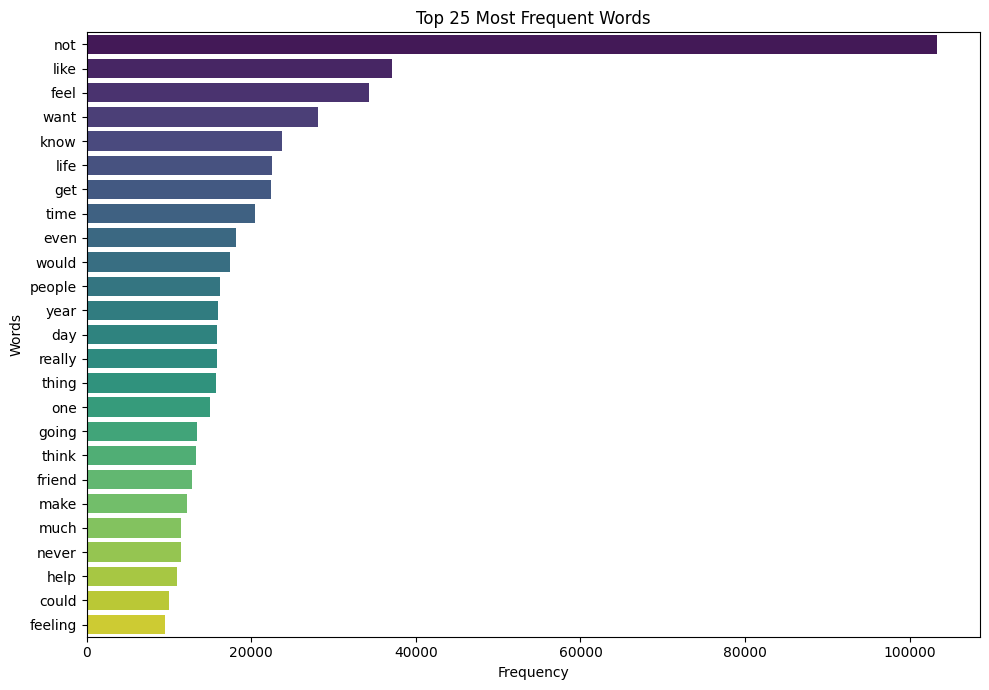

In [ ]:
from collections import Counter

def plot_word_frequency(dataframe, num_words=25):
    all_words = [w for tokens in dataframe['tokens'] for w in tokens]
    common = Counter(all_words).most_common(num_words)
    words, counts = zip(*common)
    plt.figure(figsize=(10, 7))
    sns.barplot(x=list(counts), y=list(words), palette='viridis')
    plt.title(f'Top {num_words} Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.tight_layout()
    plt.show()

plot_word_frequency(df, 25)

### 6.4 Bigrams & Trigrams

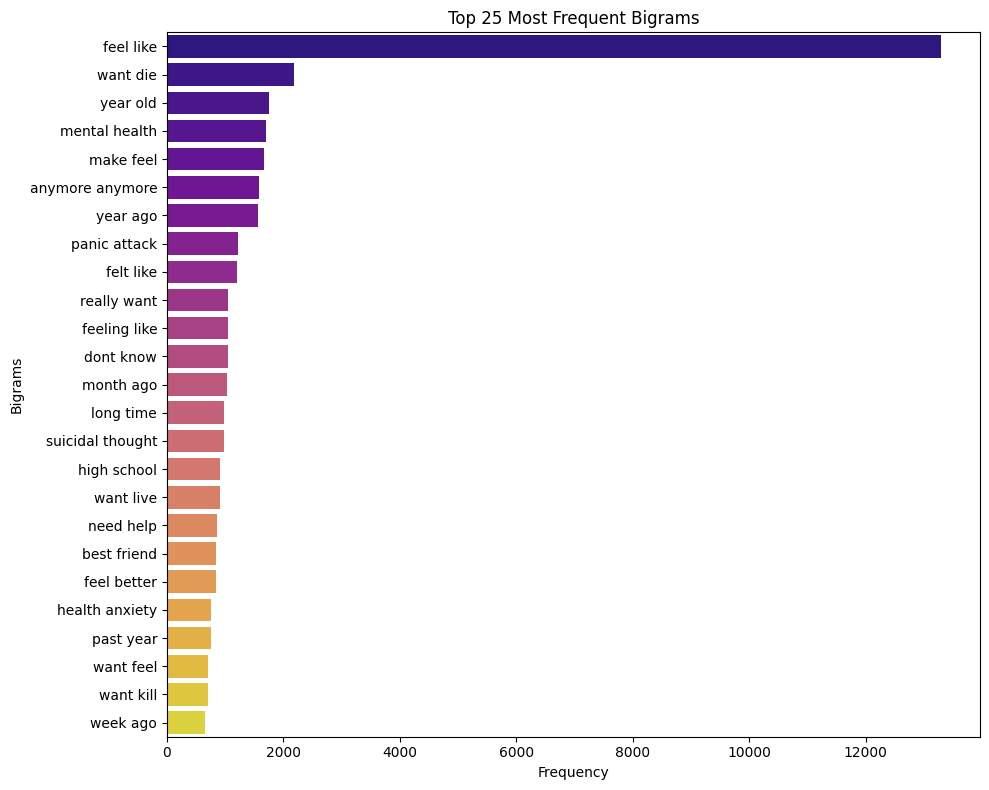

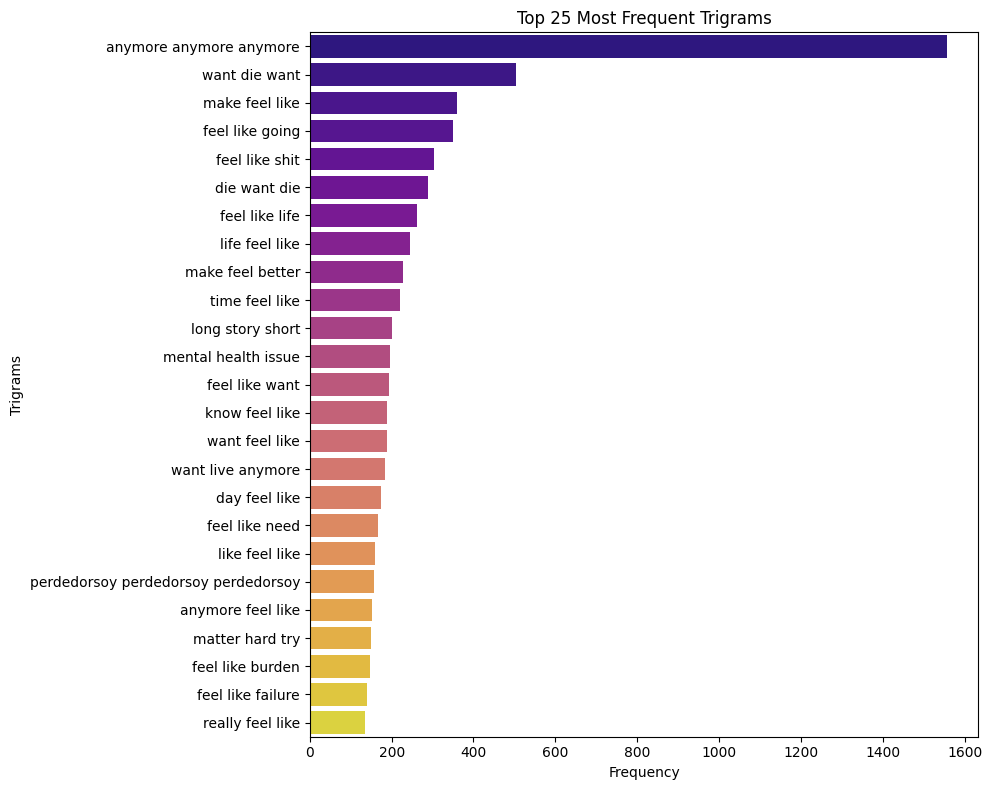

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# FIX: one clean function handles both — no copy-paste, no dead code inside
def plot_top_ngrams(corpus, ngram_range=(2, 2), num_ngrams=25, title='Bigrams'):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    names = vec.get_feature_names_out()
    ngram_df = pd.DataFrame({'ngram': names, 'count': counts})
    top = ngram_df.nlargest(num_ngrams, 'count')
    plt.figure(figsize=(10, 8))
    sns.barplot(x='count', y='ngram', data=top, palette='plasma')
    plt.title(f'Top {num_ngrams} Most Frequent {title}')
    plt.xlabel('Frequency')
    plt.ylabel(title)
    plt.tight_layout()
    plt.show()

corpus = df['clean_text'].tolist()
plot_top_ngrams(corpus, ngram_range=(2, 2), title='Bigrams')
plot_top_ngrams(corpus, ngram_range=(3, 3), title='Trigrams')

## 7. Feature Extraction

### 7.1 TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# FIX #4: max_features raised from 3000 → 15000
# Also add char n-grams via sublinear_tf for better discrimination
tfidf_vec = TfidfVectorizer(
    max_features=15000,
    sublinear_tf=True,       # log(tf)+1 — reduces impact of very common words
    ngram_range=(1, 2),      # include bigrams (e.g. 'not happy', 'feel hopeless')
    min_df=2,                # ignore terms that appear in fewer than 2 docs
)
tfidf_matrix = tfidf_vec.fit_transform(df['clean_text'])
print('TF-IDF shape:', tfidf_matrix.shape)

TF-IDF shape: (51093, 15000)


### 7.2 Bag of Words

In [ ]:
# FIX: only one CountVectorizer instantiation
bow_vec = CountVectorizer(max_features=5000)
bow_matrix = bow_vec.fit_transform(df['clean_text'])
print('BoW shape:', bow_matrix.shape)

BoW shape: (51093, 5000)


### 7.3 Word2Vec

In [ ]:
pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.1 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=df['tokens'],
    vector_size=100, window=5, min_count=2, workers=4
)

def get_avg_word2vec(tokens, model, dim=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

# FIX: store vectors in a numpy array, not in a DataFrame column
X_w2v = np.array([get_avg_word2vec(t, w2v_model) for t in df['tokens']])
print('Word2Vec matrix shape:', X_w2v.shape)

Word2Vec matrix shape: (51093, 100)


### 7.4 Doc2Vec

In [ ]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

# FIX: tags must be consistent — use integer tags throughout
tagged_data = [TaggedDocument(words=tokens, tags=[i]) for i, tokens in enumerate(df['tokens'])]

d2v_model = Doc2Vec(vector_size=100, window=5, min_count=1, workers=4, epochs=10)
d2v_model.build_vocab(tagged_data)
d2v_model.train(tagged_data, total_examples=d2v_model.corpus_count, epochs=d2v_model.epochs)

# Retrieve using integer tag — consistent with how they were tagged
X_d2v = np.array([d2v_model.dv[i] for i in range(len(df))])
print('Doc2Vec matrix shape:', X_d2v.shape)

Doc2Vec matrix shape: (51093, 100)


### 7.5 GloVe

In [ ]:
import os

if not os.path.exists('glove.6B.100d.txt'):
    import subprocess
    subprocess.run(['wget', '-q', 'http://nlp.stanford.edu/data/glove.6B.zip'])
    subprocess.run(['unzip', '-q', '-o', 'glove.6B.zip'])

glove_dict = {}
with open('glove.6B.100d.txt', 'r', encoding='utf-8') as f:
    for line in f:
        vals = line.split()
        glove_dict[vals[0]] = np.asarray(vals[1:], dtype='float32')

def get_glove_vector(text):
    vecs = [glove_dict[w] for w in text.split() if w in glove_dict]
    return np.mean(vecs, axis=0) if vecs else np.zeros(100)

X_glove = np.array([get_glove_vector(t) for t in df['clean_text']])
print('GloVe matrix shape:', X_glove.shape)

GloVe matrix shape: (51093, 100)


### 7.6 FastText

In [ ]:
from gensim.models import FastText

ft_model = FastText(
    sentences=df['tokens'],
    vector_size=100, window=5, min_count=2, workers=4
)

def fasttext_vectorize(tokens, model, dim=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

X_fasttext = np.vstack([fasttext_vectorize(t, ft_model) for t in df['tokens']])
print('FastText matrix shape:', X_fasttext.shape)

FastText matrix shape: (51093, 100)


### 7.7 BERT Embeddings (for feature extraction)

In [ ]:
import torch
from transformers import BertTokenizer, BertModel

# FIX: define device BEFORE it is used in any function
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# FIX: use a distinct variable name to avoid collision with Keras tokenizer later
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased').to(device)
bert_model.eval()

def bert_vectorize_batch(texts, batch_size=38):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = bert_tokenizer(
            batch, return_tensors='pt', truncation=True,
            padding=True, max_length=64
        ).to(device)
        with torch.no_grad():
            outputs = bert_model(**inputs)
        cls_emb = outputs.last_hidden_state[:, 0, :]
        embeddings.append(cls_emb.cpu().numpy())
    return np.vstack(embeddings)

#X_bert = bert_vectorize_batch(df['clean_text'].tolist())
#print('BERT embedding shape:', X_bert.shape)



Using device: cpu


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### 7.8 Cosine Similarity Heatmaps (representation comparison)

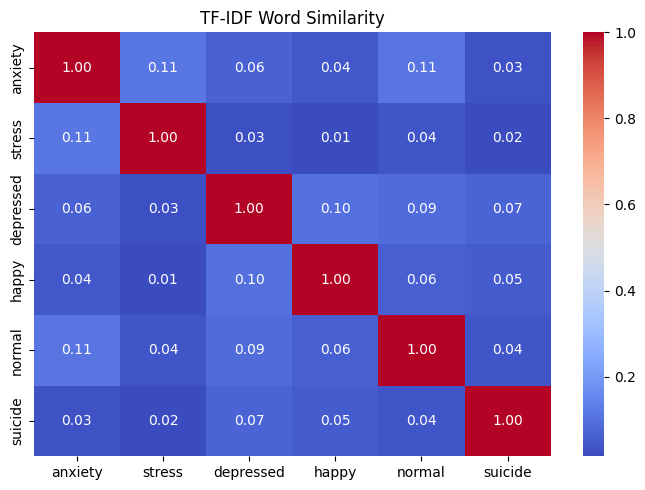

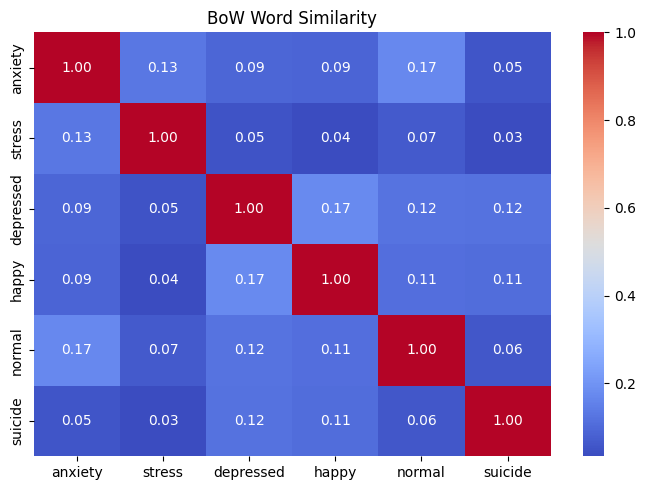

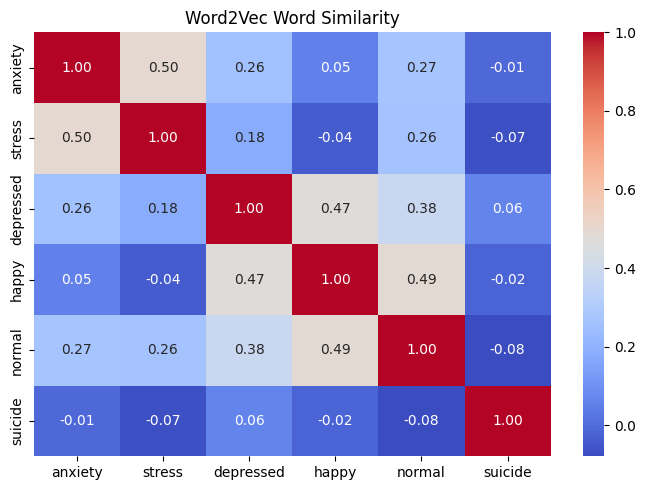

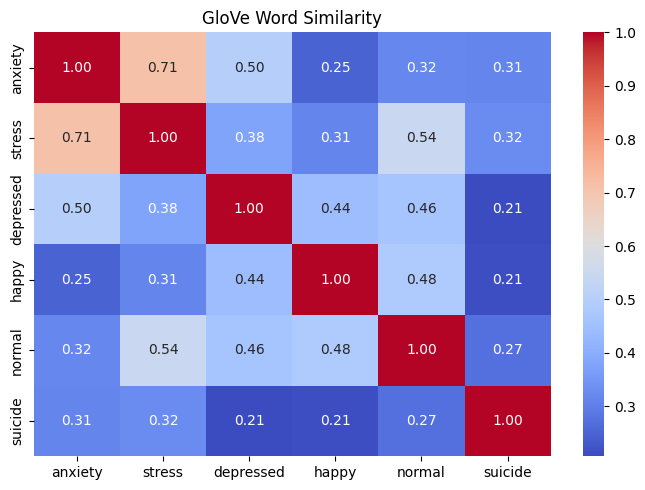

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

words = ['anxiety', 'stress', 'depressed', 'happy', 'normal', 'suicide']

def get_vector_safe(model_or_dict, word, dim=100):
    try:
        return model_or_dict[word]
    except (KeyError, TypeError):
        return np.zeros(dim)

def plot_similarity_heatmap(matrix, title, labels):
    plt.figure(figsize=(7, 5))
    sns.heatmap(matrix, cmap='coolwarm', annot=True, fmt='.2f',
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.tight_layout()
    plt.show()

tfidf_vocab = {w: i for i, w in enumerate(tfidf_vec.get_feature_names_out())}
tfidf_vecs  = [tfidf_matrix[:, tfidf_vocab[w]].toarray().flatten()
               if w in tfidf_vocab else np.zeros(tfidf_matrix.shape[0]) for w in words]
plot_similarity_heatmap(cosine_similarity(tfidf_vecs), 'TF-IDF Word Similarity', words)

bow_vocab = {w: i for i, w in enumerate(bow_vec.get_feature_names_out())}
bow_vecs  = [bow_matrix[:, bow_vocab[w]].toarray().flatten()
             if w in bow_vocab else np.zeros(bow_matrix.shape[0]) for w in words]
plot_similarity_heatmap(cosine_similarity(bow_vecs), 'BoW Word Similarity', words)

w2v_vecs   = [get_vector_safe(w2v_model.wv, w) for w in words]
plot_similarity_heatmap(cosine_similarity(w2v_vecs), 'Word2Vec Word Similarity', words)

glove_vecs = [get_vector_safe(glove_dict, w) for w in words]
plot_similarity_heatmap(cosine_similarity(glove_vecs), 'GloVe Word Similarity', words)

## 8. Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['status'])
num_classes = len(le.classes_)

print('Classes:', le.classes_)
print('Number of classes:', num_classes)

Classes: ['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']
Number of classes: 7


## 9. Machine Learning Models

### 9.1 Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

def evaluate_model(X, y, model, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    print(f'\n--- {name} ---')
    print(f'Accuracy: {acc:.4f} | F1 (weighted): {f1:.4f}')
    # FIX: add full classification report per class
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    return acc, f1

lr = lambda: LogisticRegression(max_iter=1000, class_weight='balanced')

lr_results = {}
lr_results['TF-IDF']   = evaluate_model(tfidf_matrix, y, lr(), 'TF-IDF + LR')
lr_results['BoW']      = evaluate_model(bow_matrix,   y, lr(), 'BoW + LR')
lr_results['GloVe']    = evaluate_model(X_glove,      y, lr(), 'GloVe + LR')
lr_results['Word2Vec'] = evaluate_model(X_w2v,        y, lr(), 'Word2Vec + LR')
lr_results['FastText'] = evaluate_model(X_fasttext,   y, lr(), 'FastText + LR')
#lr_results['BERT']     = evaluate_model(X_bert,       y, lr(), 'BERT + LR')


--- TF-IDF + LR ---
Accuracy: 0.7306 | F1 (weighted): 0.7299
                      precision    recall  f1-score   support

             Anxiety       0.73      0.81      0.77       725
             Bipolar       0.68      0.74      0.71       500
          Depression       0.75      0.56      0.64      3019
              Normal       0.88      0.92      0.90      3208
Personality disorder       0.42      0.59      0.49       179
              Stress       0.42      0.61      0.49       459
            Suicidal       0.64      0.69      0.66      2129

            accuracy                           0.73     10219
           macro avg       0.65      0.70      0.67     10219
        weighted avg       0.74      0.73      0.73     10219


--- BoW + LR ---
Accuracy: 0.7088 | F1 (weighted): 0.7070
                      precision    recall  f1-score   support

             Anxiety       0.69      0.73      0.71       725
             Bipolar       0.65      0.66      0.65       500
       

### 9.2 Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB

def evaluate_nb(X, y, name, nb_type='gaussian'):
    model = MultinomialNB() if nb_type == 'multinomial' else GaussianNB()
    X_arr = X.toarray() if hasattr(X, 'toarray') else X
    return evaluate_model(X_arr, y, model, name)

nb_results = {}
nb_results['TF-IDF + NB']   = evaluate_nb(tfidf_matrix, y, 'TF-IDF + NB',   'multinomial')
nb_results['BoW + NB']      = evaluate_nb(bow_matrix,   y, 'BoW + NB',      'multinomial')
# FIX: removed duplicate GloVe+NB call (was in both Cell 83 and 84)
nb_results['GloVe + NB']    = evaluate_nb(X_glove,      y, 'GloVe + NB',    'gaussian')
nb_results['Word2Vec + NB'] = evaluate_nb(X_w2v,        y, 'Word2Vec + NB', 'gaussian')
nb_results['FastText + NB'] = evaluate_nb(X_fasttext,   y, 'FastText + NB', 'gaussian')
#nb_results['BERT + NB']     = evaluate_nb(X_bert,       y, 'BERT + NB',     'gaussian')


--- TF-IDF + NB ---
Accuracy: 0.6603 | F1 (weighted): 0.6413
                      precision    recall  f1-score   support

             Anxiety       0.80      0.60      0.69       725
             Bipolar       0.91      0.30      0.45       500
          Depression       0.51      0.78      0.62      3019
              Normal       0.83      0.82      0.82      3208
Personality disorder       1.00      0.02      0.04       179
              Stress       1.00      0.03      0.06       459
            Suicidal       0.67      0.55      0.61      2129

            accuracy                           0.66     10219
           macro avg       0.82      0.44      0.47     10219
        weighted avg       0.72      0.66      0.64     10219


--- BoW + NB ---
Accuracy: 0.6623 | F1 (weighted): 0.6648
                      precision    recall  f1-score   support

             Anxiety       0.67      0.75      0.71       725
             Bipolar       0.57      0.69      0.62       500
       

### 9.3 SVM (SGDClassifier)

In [ ]:
from sklearn.linear_model import SGDClassifier

svm_results = {}

def evaluate_svm(X, y, name):
    X_arr = X.toarray() if hasattr(X, 'toarray') else X
    model = SGDClassifier(loss='hinge', class_weight='balanced',
                          max_iter=1000, random_state=42)
    return evaluate_model(X_arr, y, model, name)

svm_results['TF-IDF']   = evaluate_svm(tfidf_matrix, y, 'TF-IDF + SVM')
svm_results['BoW']      = evaluate_svm(bow_matrix,   y, 'BoW + SVM')
svm_results['GloVe']    = evaluate_svm(X_glove,      y, 'GloVe + SVM')
svm_results['Word2Vec'] = evaluate_svm(X_w2v,        y, 'Word2Vec + SVM')
svm_results['FastText'] = evaluate_svm(X_fasttext,   y, 'FastText + SVM')
#svm_results['BERT']     = evaluate_svm(X_bert,       y, 'BERT + SVM')


--- TF-IDF + SVM ---
Accuracy: 0.7059 | F1 (weighted): 0.7046
                      precision    recall  f1-score   support

             Anxiety       0.72      0.82      0.77       725
             Bipolar       0.67      0.75      0.71       500
          Depression       0.79      0.47      0.59      3019
              Normal       0.83      0.94      0.88      3208
Personality disorder       0.21      0.75      0.33       179
              Stress       0.46      0.54      0.50       459
            Suicidal       0.64      0.68      0.66      2129

            accuracy                           0.71     10219
           macro avg       0.62      0.71      0.63     10219
        weighted avg       0.74      0.71      0.70     10219


--- BoW + SVM ---
Accuracy: 0.7039 | F1 (weighted): 0.6985
                      precision    recall  f1-score   support

             Anxiety       0.64      0.78      0.70       725
             Bipolar       0.63      0.66      0.65       500
     

### 9.4 Results Comparison

          Accuracy  F1-score
TF-IDF    0.705940  0.704618
BoW       0.703885  0.698538
FastText  0.562090  0.566784
Word2Vec  0.529700  0.507613
GloVe     0.482728  0.492170


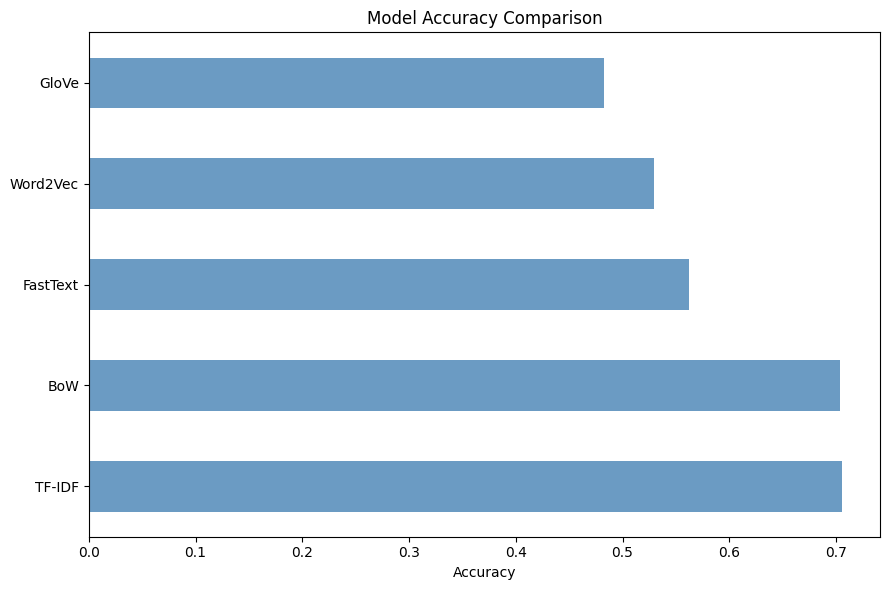

In [ ]:
all_results = {**lr_results, **svm_results}
results_df = pd.DataFrame(all_results, index=['Accuracy', 'F1-score']).T
results_df = results_df.sort_values('Accuracy', ascending=False)
print(results_df)

# FIX: bar chart for visual comparison
results_df['Accuracy'].plot(kind='barh', figsize=(9, 6), color='steelblue', alpha=0.8)
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.tight_layout()
plt.show()

## 10. Deep Learning Models

### 10.1 Keras Tokenizer & Padding

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 20000
max_len   = 150

keras_tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
keras_tokenizer.fit_on_texts(df['clean_text'])

X_seq = keras_tokenizer.texts_to_sequences(df['clean_text'])

X_pad = pad_sequences(
    X_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

print("X_pad shape:", X_pad.shape)

X_pad shape: (51093, 150)


In [ ]:
# 🔥 ADD THIS PART (VERY IMPORTANT)
tokenizer_json = keras_tokenizer.to_json()

import os
os.makedirs("mental_health_artifacts", exist_ok=True)

with open("mental_health_artifacts/keras_tokenizer.json", "w") as f:
    f.write(tokenizer_json)

print("✅ Tokenizer saved as JSON")

✅ Tokenizer saved as JSON


### 10.2 — GloVe Embedding Matrix

In [ ]:
EMBED_DIM   = 100
vocab_size  = min(max_words, len(keras_tokenizer.word_index) + 1)
embed_matrix = np.zeros((vocab_size, EMBED_DIM))

hit, miss = 0, 0
for word, idx in keras_tokenizer.word_index.items():
    if idx >= max_words:
        continue
    vec = glove_dict.get(word)
    if vec is not None:
        embed_matrix[idx] = vec
        hit += 1
    else:
        miss += 1

print(f'Embedding matrix : {embed_matrix.shape}')
print(f'GloVe coverage   : {hit/(hit+miss)*100:.1f}%  ({hit} found, {miss} missing)')

Embedding matrix : (20000, 100)
GloVe coverage   : 85.9%  (17180 found, 2819 missing)


In [ ]:
from sklearn.model_selection import train_test_split

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_pad, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

###10.3 — Class Weights & Callbacks

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

class_weights    = compute_class_weight('balanced', classes=np.unique(y_train_dl), y=y_train_dl)
class_weight_dict = dict(enumerate(class_weights))
print('Class weights:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls:25s}: {class_weight_dict[i]:.4f}')

def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ]

Class weights:
  Anxiety                  : 2.0149
  Bipolar                  : 2.9181
  Depression               : 0.4836
  Normal                   : 0.4550
  Personality disorder     : 8.1552
  Stress                   : 3.1786
  Suicidal                 : 0.6857


###10.4 Custom Attention Layer

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class BahdanauAttention(Layer):
    """
    Additive (Bahdanau) self-attention.
    Input  shape: (batch, timesteps, features)
    Output shape: (batch, features)
    """
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.W = tf.keras.layers.Dense(units, use_bias=False)
        self.V = tf.keras.layers.Dense(1,     use_bias=False)

    def call(self, encoder_output):
        score   = self.V(tf.nn.tanh(self.W(encoder_output)))  # (B, T, 1)
        weights = tf.nn.softmax(score, axis=1)                 # (B, T, 1)
        context = weights * encoder_output                     # (B, T, F)
        return tf.reduce_sum(context, axis=1)                  # (B, F)

    def get_config(self):
        return {**super().get_config(), 'units': self.units}

print('BahdanauAttention layer defined.')

BahdanauAttention layer defined.


### 10.2 LSTM + Attention Model

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, GRU, Dense,
    Dropout, Bidirectional, BatchNormalization
)
from tensorflow.keras.optimizers import Adam

inp = Input(shape=(max_len,))

x = Embedding(input_dim=vocab_size, output_dim=EMBED_DIM,
              weights=[embed_matrix], trainable=True)(inp)
x = Bidirectional(LSTM(64, dropout=0.2, return_sequences=True))(x)
x = BatchNormalization()(x)
x = BahdanauAttention(units=64)(x)
x = Dropout(0.4)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(num_classes, activation='softmax')(x)

model_lstm = Model(inp, out)
model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)
model_lstm.summary()

history_lstm = model_lstm.fit(
    X_train_dl, y_train_dl,
    epochs=20, batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 150, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 150, 128)       │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bahdanau_attention              │ (None, 128)            │         8,256 │
│ (BahdanauAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,101,959 (8.02 MB)

 Trainable params: 2,101,703 (8.02 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 307s 522ms/step - accuracy: 0.4344 - loss: 1.5906 - val_accuracy: 0.5751 - val_loss: 1.1678 - learning_rate: 5.0000e-04
Epoch 2/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 311s 542ms/step - accuracy: 0.5757 - loss: 1.1701 - val_accuracy: 0.6419 - val_loss: 0.9646 - learning_rate: 5.0000e-04
Epoch 3/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 291s 506ms/step - accuracy: 0.6353 - loss: 0.9604 - val_accuracy: 0.6641 - val_loss: 0.9092 - learning_rate: 5.0000e-04
Epoch 4/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 293s 510ms/step - accuracy: 0.6591 - loss: 0.8812 - val_accuracy: 0.6715 - val_loss: 0.8527 - learning_rate: 5.0000e-04
Epoch 5/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 293s 510ms/step - accuracy: 0.6762 - loss: 0.8005 - val_accuracy: 0.6871 - val_loss: 0.8124 - learning_rate: 5.0000e-04
Epoch 6/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 291s 505ms/step - accuracy: 0.6899 - loss: 0.7349 - val_accuracy: 0.6810 - val_loss: 0.7737 - learning_rate: 5.0000e-04
Epoch 7/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 

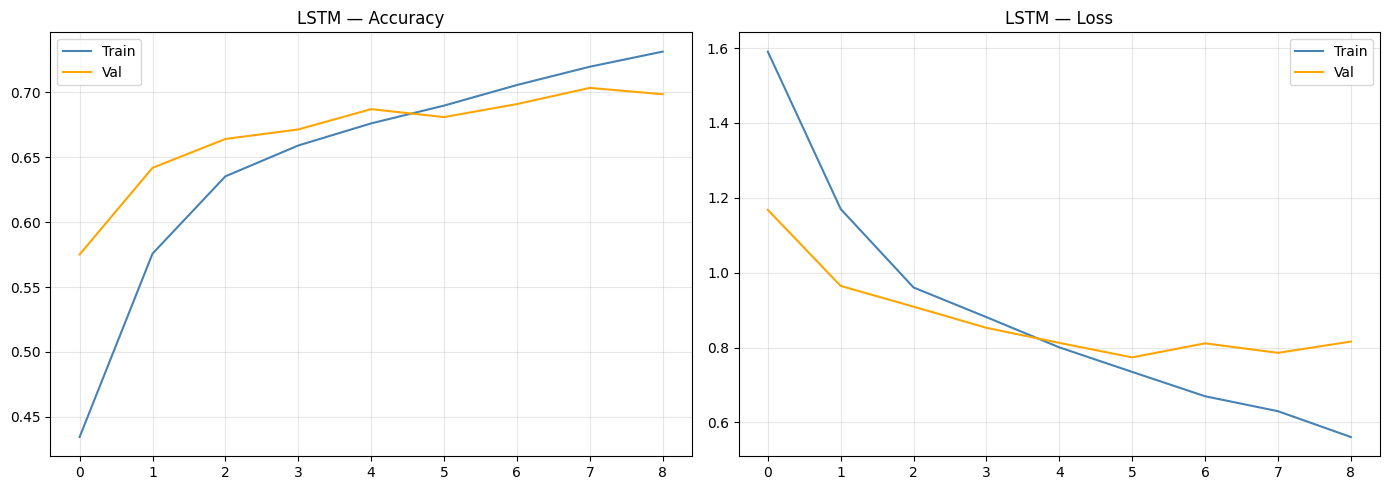

Best val accuracy: 0.7035


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_lstm.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history_lstm.history['val_accuracy'], label='Val',   color='orange')
axes[0].set_title('LSTM — Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_lstm.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history_lstm.history['val_loss'], label='Val',   color='orange')
axes[1].set_title('LSTM — Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=100)
plt.show()
print(f'Best val accuracy: {max(history_lstm.history["val_accuracy"]):.4f}')

LSTM Test Accuracy: 0.6909
320/320 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.70      0.86      0.77       725
             Bipolar       0.67      0.77      0.71       500
          Depression       0.83      0.34      0.48      3019
              Normal       0.92      0.89      0.90      3208
Personality disorder       0.30      0.63      0.41       179
              Stress       0.40      0.62      0.48       459
            Suicidal       0.53      0.83      0.65      2129

            accuracy                           0.69     10219
           macro avg       0.62      0.70      0.63     10219
        weighted avg       0.75      0.69      0.68     10219



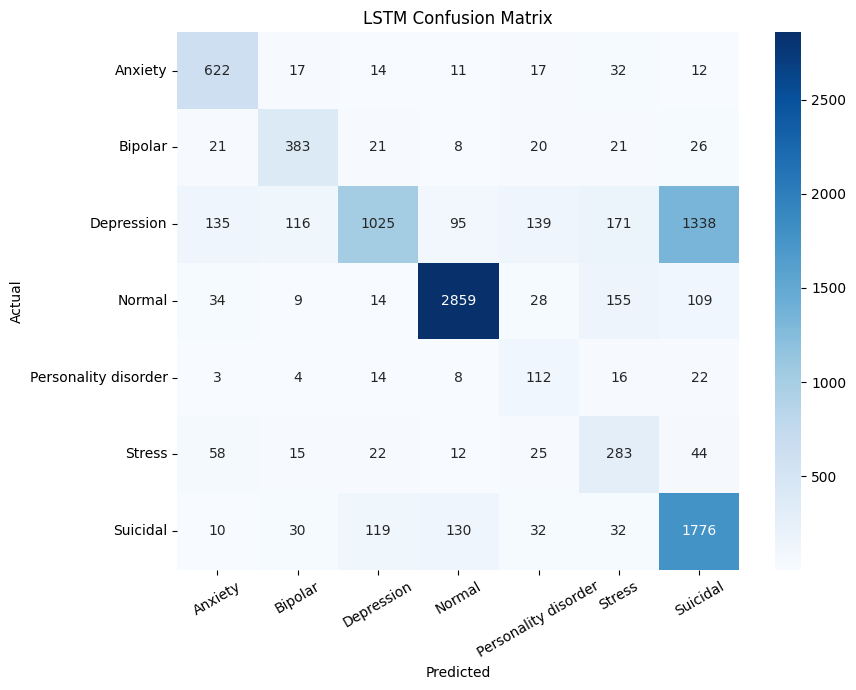

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

loss, acc = model_lstm.evaluate(X_test_dl, y_test_dl, verbose=0)
print(f'LSTM Test Accuracy: {acc:.4f}')

y_pred_lstm = np.argmax(model_lstm.predict(X_test_dl), axis=1)
print('\nClassification Report:')
print(classification_report(y_test_dl, y_pred_lstm, target_names=le.classes_))

cm = confusion_matrix(y_test_dl, y_pred_lstm)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

### 10.3 GRU + Attention Model

In [ ]:
inp_gru = Input(shape=(max_len,))

x_g = Embedding(input_dim=vocab_size, output_dim=EMBED_DIM,
                weights=[embed_matrix], trainable=True)(inp_gru)
x_g = Bidirectional(GRU(64, dropout=0.2, return_sequences=True))(x_g)
x_g = BatchNormalization()(x_g)
x_g = BahdanauAttention(units=64)(x_g)
x_g = Dropout(0.4)(x_g)
x_g = Dense(64, activation='relu')(x_g)
x_g = Dropout(0.3)(x_g)
out_gru = Dense(num_classes, activation='softmax')(x_g)

model_gru = Model(inp_gru, out_gru)
model_gru.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

history_gru = model_gru.fit(
    X_train_dl, y_train_dl,
    epochs=20, batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)

Epoch 1/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 359s 600ms/step - accuracy: 0.4603 - loss: 1.5915 - val_accuracy: 0.6331 - val_loss: 1.0071 - learning_rate: 5.0000e-04
Epoch 2/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 455s 791ms/step - accuracy: 0.6028 - loss: 1.1197 - val_accuracy: 0.6455 - val_loss: 0.9950 - learning_rate: 5.0000e-04
Epoch 3/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 300s 438ms/step - accuracy: 0.6390 - loss: 0.9852 - val_accuracy: 0.6646 - val_loss: 0.8944 - learning_rate: 5.0000e-04
Epoch 4/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 259s 451ms/step - accuracy: 0.6592 - loss: 0.8863 - val_accuracy: 0.6678 - val_loss: 0.8932 - learning_rate: 5.0000e-04
Epoch 5/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 251s 436ms/step - accuracy: 0.6765 - loss: 0.8140 - val_accuracy: 0.6566 - val_loss: 0.8505 - learning_rate: 5.0000e-04
Epoch 6/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 249s 433ms/step - accuracy: 0.6884 - loss: 0.7599 - val_accuracy: 0.6820 - val_loss: 0.8303 - learning_rate: 5.0000e-04
Epoch 7/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 

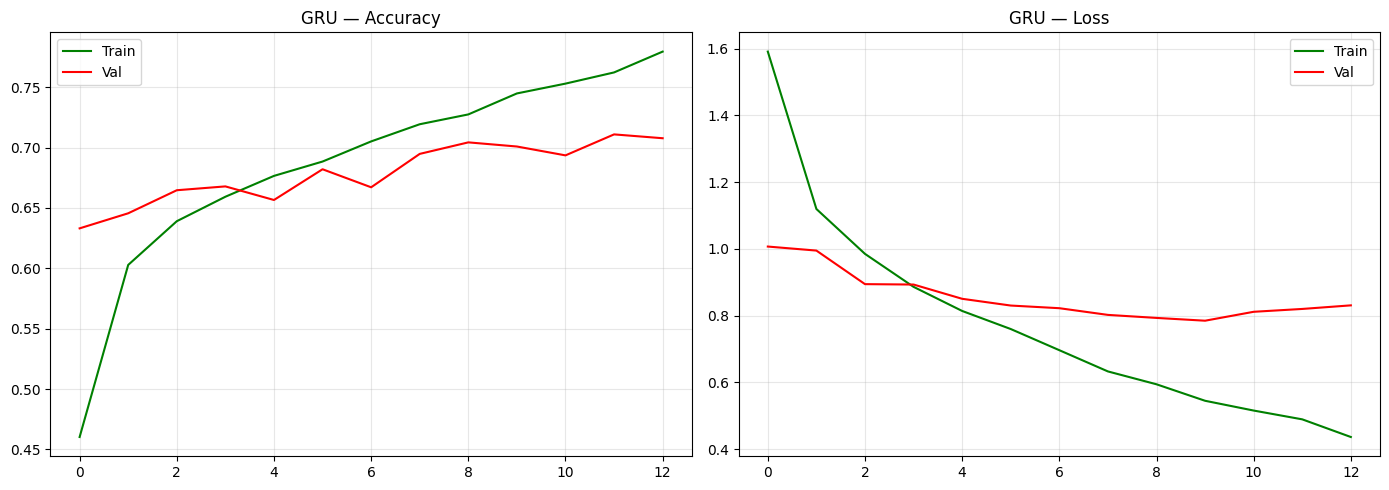

Best val accuracy: 0.7109


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_gru.history['accuracy'],     label='Train', color='green')
axes[0].plot(history_gru.history['val_accuracy'], label='Val',   color='red')
axes[0].set_title('GRU — Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_gru.history['loss'],     label='Train', color='green')
axes[1].plot(history_gru.history['val_loss'], label='Val',   color='red')
axes[1].set_title('GRU — Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gru_training_curves.png', dpi=100)
plt.show()
print(f'Best val accuracy: {max(history_gru.history["val_accuracy"]):.4f}')

GRU Test Accuracy: 0.7039
320/320 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.71      0.85      0.77       725
             Bipolar       0.69      0.77      0.72       500
          Depression       0.78      0.41      0.54      3019
              Normal       0.92      0.89      0.90      3208
Personality disorder       0.44      0.56      0.49       179
              Stress       0.36      0.67      0.47       459
            Suicidal       0.56      0.80      0.66      2129

            accuracy                           0.70     10219
           macro avg       0.64      0.71      0.65     10219
        weighted avg       0.75      0.70      0.70     10219



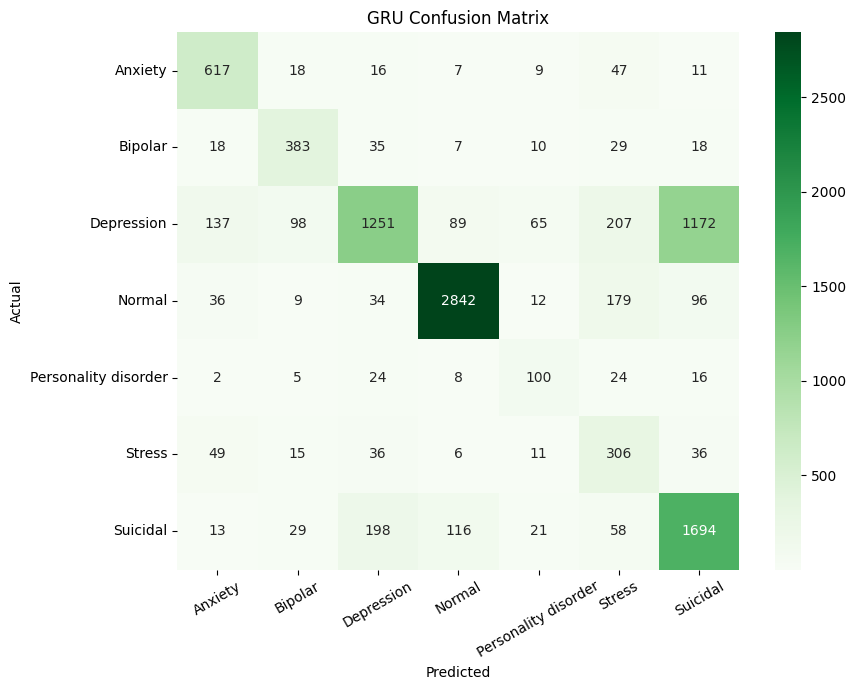

In [ ]:
loss, acc = model_gru.evaluate(X_test_dl, y_test_dl, verbose=0)
print(f'GRU Test Accuracy: {acc:.4f}')

y_pred_gru = np.argmax(model_gru.predict(X_test_dl), axis=1)
print('\nClassification Report:')
print(classification_report(y_test_dl, y_pred_gru, target_names=le.classes_))

cm_gru = confusion_matrix(y_test_dl, y_pred_gru)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_gru, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('GRU Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

###10.9 Final Model Comparison

       FINAL MODEL COMPARISON
Logistic Regression + TF-IDF : ~75%
LSTM + Attention              : 70.35%
GRU  + Attention              : 71.09%


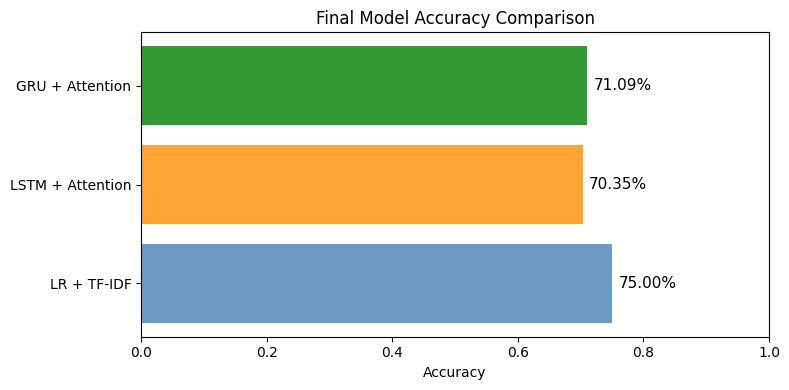

In [ ]:
lstm_acc = max(history_lstm.history['val_accuracy'])
gru_acc  = max(history_gru.history['val_accuracy'])

print('=' * 50)
print('       FINAL MODEL COMPARISON')
print('=' * 50)
print(f'Logistic Regression + TF-IDF : ~75%')
print(f'LSTM + Attention              : {lstm_acc:.2%}')
print(f'GRU  + Attention              : {gru_acc:.2%}')
print('=' * 50)

models = ['LR + TF-IDF', 'LSTM + Attention', 'GRU + Attention']
accs   = [0.75, lstm_acc, gru_acc]
colors = ['steelblue', 'darkorange', 'green']

plt.figure(figsize=(8, 4))
bars = plt.barh(models, accs, color=colors, alpha=0.8)
plt.xlabel('Accuracy')
plt.title('Final Model Accuracy Comparison')
plt.xlim(0, 1.0)
for bar, a in zip(bars, accs):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{a:.2%}', va='center', fontsize=11)
plt.tight_layout()
plt.show()

###11.Inference — Predict on New Text

In [ ]:
def predict_mental_health(text, model='lstm'):
    """
    Predict mental health status from raw text.
    Uses the SAME preprocess() and keras_tokenizer as training.
    FIX: model parameter now actually selects the model.
    """
    clean  = preprocess(text)
    seq    = keras_tokenizer.texts_to_sequences([clean])
    padded = pad_sequences(seq, maxlen=max_len)

    # FIX: actually use the model parameter
    chosen_model = model_lstm if model == 'lstm' else model_gru

    probs      = chosen_model.predict(padded, verbose=0)[0]
    pred_idx   = np.argmax(probs)
    pred_label = le.classes_[pred_idx]
    confidence = probs[pred_idx]

    print(f'Input      : {text}')
    print(f'Cleaned    : {clean}')
    print(f'Model      : {model.upper()}')
    print(f'Prediction : {pred_label} ({confidence:.2%} confidence)')
    print('-' * 60)
    return pred_label

# ── LSTM test inputs ──
print('=' * 60)
print('           LSTM MODEL — VALIDATION INPUTS')
print('=' * 60)
predict_mental_health("I have been feeling empty and worthless for weeks now.",            model='lstm')
predict_mental_health("Nothing makes me happy anymore, I just stay in bed all day.",       model='lstm')
predict_mental_health("I have been having panic attacks and constant worry.",              model='lstm')
predict_mental_health("I feel so hopeless and can't sleep at all lately.",                 model='lstm')
predict_mental_health("I don't see any point in continuing, everything feels meaningless.",model='lstm')
predict_mental_health("I have too many deadlines, I feel completely burned out.",          model='lstm')
predict_mental_health("My mood switches fast, one moment energetic, next devastated.",     model='lstm')
predict_mental_health("I feel like I don't know who I am, my identity keeps changing.",    model='lstm')
predict_mental_health("I am doing great today, feeling very energetic and happy!",         model='lstm')
predict_mental_health("Had a wonderful day with family, feeling grateful and content.",    model='lstm')

# ── GRU test inputs ──
print('=' * 60)
print('           GRU MODEL — VALIDATION INPUTS')
print('=' * 60)
predict_mental_health("I have been feeling empty and worthless for weeks now.",            model='gru')
predict_mental_health("Nothing makes me happy anymore, I just stay in bed all day.",       model='gru')
predict_mental_health("I have been having panic attacks and constant worry.",              model='gru')
predict_mental_health("I feel so hopeless and can't sleep at all lately.",                 model='gru')
predict_mental_health("I don't see any point in continuing, everything feels meaningless.",model='gru')
predict_mental_health("I have too many deadlines, I feel completely burned out.",          model='gru')
predict_mental_health("My mood switches fast, one moment energetic, next devastated.",     model='gru')
predict_mental_health("I feel like I don't know who I am, my identity keeps changing.",    model='gru')
predict_mental_health("I am doing great today, feeling very energetic and happy!",         model='gru')
predict_mental_health("Had a wonderful day with family, feeling grateful and content.",    model='gru')

           LSTM MODEL — VALIDATION INPUTS
Input      : I have been feeling empty and worthless for weeks now.
Cleaned    : feeling empty worthless week
Model      : LSTM
Prediction : Normal (97.74% confidence)
------------------------------------------------------------
Input      : Nothing makes me happy anymore, I just stay in bed all day.
Cleaned    : nothing make happy anymore stay bed day
Model      : LSTM
Prediction : Normal (97.72% confidence)
------------------------------------------------------------
Input      : I have been having panic attacks and constant worry.
Cleaned    : panic attack constant worry
Model      : LSTM
Prediction : Anxiety (60.34% confidence)
------------------------------------------------------------
Input      : I feel so hopeless and can't sleep at all lately.
Cleaned    : feel hopeless not sleep lately
Model      : LSTM
Prediction : Normal (92.57% confidence)
------------------------------------------------------------
Input      : I don't see any po

'Normal'

###12. Save Artifacts for HuggingFace Spaces

In [ ]:
#Install required libraries
!pip install gradio joblib -q
print('✅ Gradio and Joblib installed')

✅ Gradio and Joblib installed


In [ ]:
import os
import joblib

# Create artifacts folder
os.makedirs('mental_health_artifacts', exist_ok=True)

# =========================
# 1. SAVE MODELS (SavedModel format)
# =========================

# ⚠️ Correct for Hugging Face (avoid .h5)
model_lstm.export('mental_health_artifacts/lstm_savedmodel')
print('✅ LSTM saved (SavedModel format)')

model_gru.export('mental_health_artifacts/gru_savedmodel')
print('✅ GRU saved (SavedModel format)')


# =========================
# 2. SAVE TOKENIZER (JSON)
# =========================

tokenizer_json = keras_tokenizer.to_json()

with open("mental_health_artifacts/keras_tokenizer.json", "w") as f:
    f.write(tokenizer_json)

print('✅ Tokenizer saved')


# =========================
# 3. SAVE LABEL ENCODER
# =========================

joblib.dump(le, 'mental_health_artifacts/label_encoder.pkl')
print('✅ Label encoder saved')


# =========================
# 4. SAVE CONFIG (IMPORTANT)
# =========================

joblib.dump({
    'max_len'       : max_len,
    'max_words'     : max_words,
    'contractions'  : CONTRACTIONS,
    'negation_words': list(NEGATION_WORDS),
}, 'mental_health_artifacts/config.pkl')

print('✅ Config saved')


# =========================
# 5. VERIFY FILES
# =========================

print('\n📂 Artifacts folder contains:')
print(os.listdir('mental_health_artifacts'))

Saved artifact at 'mental_health_artifacts/lstm_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  139550373032400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139549632124048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139549632125008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139549632125584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139549632126928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139549632122896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139549632124624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139549632127120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139549632127312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139549632126544: TensorSpec(shape=(), dtype=tf.resource, name=None)
 

###12.1 Quick Reload Test (verify before upload)

In [ ]:
from keras.layers import TFSMLayer
import tensorflow as tf

# Step 1: Load from existing SavedModel directories using TFSMLayer
lstm_tfsm = TFSMLayer('mental_health_artifacts/lstm_savedmodel', call_endpoint='serving_default')
gru_tfsm  = TFSMLayer('mental_health_artifacts/gru_savedmodel',  call_endpoint='serving_default')
print('✅ TFSMLayer wrappers created')

# Step 2: Wrap each in a full Keras model so we can .save() properly
inp = tf.keras.Input(shape=(150,), dtype='int32')

lstm_out    = lstm_tfsm(inp)
lstm_tensor = list(lstm_out.values())[0] if isinstance(lstm_out, dict) else lstm_out
lstm_model  = tf.keras.Model(inputs=inp, outputs=lstm_tensor)

gru_out    = gru_tfsm(inp)
gru_tensor = list(gru_out.values())[0] if isinstance(gru_out, dict) else gru_out
gru_model  = tf.keras.Model(inputs=inp, outputs=gru_tensor)

print('✅ Wrapper models built')
print('   LSTM output shape:', lstm_model.output_shape)
print('   GRU  output shape:', gru_model.output_shape)

# Step 3: Re-save as .keras (Keras 3 native format)
lstm_model.save('mental_health_artifacts/model.keras')
gru_model.save('mental_health_artifacts/gru_model.keras')
print('✅ Saved as .keras')

# Step 4: Verify reload
test_lstm = tf.keras.models.load_model('mental_health_artifacts/model.keras', safe_mode=False)
test_gru  = tf.keras.models.load_model('mental_health_artifacts/gru_model.keras', safe_mode=False)
print('✅ LSTM reloads OK — output shape:', test_lstm.output_shape)
print('✅ GRU  reloads OK — output shape:', test_gru.output_shape)

✅ TFSMLayer wrappers created
✅ Wrapper models built
   LSTM output shape: (None, 7)
   GRU  output shape: (None, 7)
✅ Saved as .keras
✅ LSTM reloads OK — output shape: (None, 7)
✅ GRU  reloads OK — output shape: (None, 7)


###12.2 Download Artifacts ZIP

In [ ]:
import shutil
from google.colab import files as colab_files   # FIX: renamed to avoid conflict with artifact_files list below

shutil.make_archive('mental_health_artifacts', 'zip', '.', 'mental_health_artifacts')
colab_files.download('mental_health_artifacts.zip')
print('✅ Downloaded! Upload this zip contents.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded! Upload this zip contents to HuggingFace Spaces.


###13. Gradio App (test locally in Colab)

In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

STATUS_META = {
    'Normal'              : ('🟢', 'No mental health concern detected. You seem to be doing well!'),
    'Depression'          : ('🔵', 'Signs of depression detected. Please consider speaking to a professional.'),
    'Anxiety'             : ('🟡', 'Signs of anxiety detected. Try breathing exercises and seek support.'),
    'Suicidal'            : ('🔴', 'Urgent: Please contact a mental health professional immediately.'),
    'Stress'              : ('🟠', 'High stress levels detected. Take breaks and practice self-care.'),
    'Bipolar'             : ('🟣', 'Bipolar patterns detected. Consistent professional support is recommended.'),
    'Personality disorder': ('🔵', 'Personality disorder signs detected. Professional therapy can help greatly.'),
}

def gradio_predict(text, model_choice):
    if not text.strip():
        return 'Please enter some text.', '', {}
    clean      = preprocess(text)
    seq        = keras_tokenizer.texts_to_sequences([clean])
    padded     = pad_sequences(seq, maxlen=max_len)
    model = model_lstm if model_choice == 'LSTM' else model_gru
    probs      = model.predict(padded, verbose=0)[0]
    idx        = int(np.argmax(probs))
    label      = le.classes_[idx]
    confidence = float(probs[idx])
    emoji, msg = STATUS_META.get(label, ('❓', ''))
    result     = f'{emoji}  {label}  ({confidence:.2%} confidence)'
    prob_dict  = {le.classes_[i]: float(probs[i]) for i in range(len(probs))}
    return result, msg, prob_dict

examples = [
    ['I feel completely hopeless and do not want to get out of bed.',      'LSTM'],
    ['I am doing great today, feeling very happy and grateful!',            'GRU'],
    ['I have constant panic attacks and cannot stop worrying.',             'LSTM'],
    ['I do not see any point in continuing, everything feels meaningless.', 'LSTM'],
    ['My mood switches so fast, one moment energetic, next devastated.',    'GRU'],
    ['I feel like I do not know who I am, my identity keeps changing.',     'GRU'],
    ['Too many deadlines, I feel completely burned out at work.',           'LSTM'],
]

with gr.Blocks(title='Mental Health Detection', theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🧠 Mental Health Detection
    **Semantic Analysis using NLP — LSTM & GRU Models with Attention**
    Detects: `Normal` | `Depression` | `Anxiety` | `Suicidal` | `Stress` | `Bipolar` | `Personality Disorder`
    ---
    """)
    with gr.Row():
        with gr.Column(scale=2):
            text_input  = gr.Textbox(label='Enter your statement',
                                     placeholder='Type how you are feeling today...',
                                     lines=4)
            model_radio = gr.Radio(choices=['LSTM', 'GRU'], value='LSTM', label='Choose Model')
            analyze_btn = gr.Button('🔍 Analyze', variant='primary')
        with gr.Column(scale=2):
            result_out = gr.Textbox(label='Prediction',          interactive=False)
            advice_out = gr.Textbox(label='Advice',              interactive=False, lines=2)
            prob_chart = gr.Label( label='Confidence per Class', num_top_classes=7)

    gr.Examples(examples=examples, inputs=[text_input, model_radio], label='Try Example Inputs')
    gr.Markdown('---\n⚠️ *For educational purposes only. Always consult a mental health professional.*')

    analyze_btn.click(
        fn=gradio_predict,
        inputs=[text_input, model_radio],
        outputs=[result_out, advice_out, prob_chart]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8836995893e27c3dbb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ── NEW CELL: Write app.py to disk so it can be launched via CMD ──
app_code = r'''
import gradio as gr
import numpy as np
import joblib
import json
import re
import string
import os
import nltk

nltk.download("stopwords", quiet=True)
nltk.download("wordnet",   quiet=True)

from nltk.corpus import stopwords
from nltk.stem   import WordNetLemmatizer
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import tokenizer_from_json

# ── Load artifacts ──────────────────────────────────────
ARTIFACTS = "mental_health_artifacts"

# Load tokenizer from JSON (how _8_ notebook saves it)
with open(f"{ARTIFACTS}/keras_tokenizer.json", "r") as f:
    tokenizer = tokenizer_from_json(f.read())

le     = joblib.load(f"{ARTIFACTS}/label_encoder.pkl")
config = joblib.load(f"{ARTIFACTS}/config.pkl")

max_len        = config["max_len"]
CONTRACTIONS   = config["contractions"]
NEGATION_WORDS = set(config["negation_words"])

lstm_model = load_model(f"{ARTIFACTS}/model.keras",     safe_mode=False)
gru_model  = load_model(f"{ARTIFACTS}/gru_model.keras", safe_mode=False)
print("✅ All artifacts loaded")

# ── Preprocessing (same as training) ────────────────────
stop_words = set(stopwords.words("english")) - NEGATION_WORDS
lemmatizer = WordNetLemmatizer()

def expand_contractions(text):
    for c, e in CONTRACTIONS.items():
        text = re.sub(r"\b" + re.escape(c) + r"\b", e, text)
    return text

def preprocess(text):
    text = str(text).lower()
    text = text.encode("ascii","ignore").decode()
    text = expand_contractions(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = text.translate(str.maketrans("","",string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w)>2 and w.isalpha()]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

# ── Status metadata ──────────────────────────────────────
STATUS_META = {
    "Normal"              : ("🟢", "No mental health concern detected. You seem to be doing well!"),
    "Depression"          : ("🔵", "Signs of depression detected. Please consider speaking to a professional."),
    "Anxiety"             : ("🟡", "Signs of anxiety detected. Try breathing exercises and seek support."),
    "Suicidal"            : ("🔴", "Urgent: Please contact a mental health professional immediately."),
    "Stress"              : ("🟠", "High stress levels detected. Take breaks and practice self-care."),
    "Bipolar"             : ("🟣", "Bipolar patterns detected. Consistent professional support is recommended."),
    "Personality disorder": ("🔵", "Personality disorder signs detected. Professional therapy can help greatly."),
}

# ── Prediction function ──────────────────────────────────
def gradio_predict(text, model_choice):
    if not text or not text.strip():
        return "Please enter some text.", "", {}
    clean  = preprocess(text)
    seq    = tokenizer.texts_to_sequences([clean])
    padded = pad_sequences(seq, maxlen=max_len)
    model  = lstm_model if model_choice == "LSTM" else gru_model
    probs  = model.predict(padded, verbose=0)[0]
    idx    = int(np.argmax(probs))
    label  = le.classes_[idx]
    conf   = float(probs[idx])
    emoji, msg = STATUS_META.get(label, ("❓", ""))
    result     = f"{emoji}  {label}  ({conf:.2%} confidence)"
    prob_dict  = {le.classes_[i]: float(probs[i]) for i in range(len(probs))}
    return result, msg, prob_dict

# ── Gradio UI ────────────────────────────────────────────
examples = [
    ["I feel completely hopeless and do not want to get out of bed.",       "LSTM"],
    ["I am doing great today, feeling very happy and grateful!",             "GRU"],
    ["I have constant panic attacks and cannot stop worrying.",              "LSTM"],
    ["I do not see any point in continuing, everything feels meaningless.",  "LSTM"],
    ["My mood switches so fast, one moment energetic, next devastated.",     "GRU"],
    ["I feel like I do not know who I am, my identity keeps changing.",      "GRU"],
    ["Too many deadlines, I feel completely burned out at work.",            "LSTM"],
]

with gr.Blocks(title="Mental Health Detection", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🧠 Mental Health Detection
    **Semantic Analysis using NLP — LSTM & GRU Models with Attention**
    Detects: `Normal` | `Depression` | `Anxiety` | `Suicidal` | `Stress` | `Bipolar` | `Personality Disorder`
    ---
    """)
    with gr.Row():
        with gr.Column(scale=2):
            text_input  = gr.Textbox(label="Enter your statement",
                                     placeholder="Type how you are feeling today...",
                                     lines=4)
            model_radio = gr.Radio(choices=["LSTM", "GRU"], value="LSTM", label="Choose Model")
            with gr.Row():
                analyze_btn = gr.Button("🔍 Analyze", variant="primary")
                clear_btn   = gr.Button("🗑️ Clear",   variant="secondary")
        with gr.Column(scale=2):
            result_out = gr.Textbox(label="Prediction",          interactive=False)
            advice_out = gr.Textbox(label="Advice",              interactive=False, lines=2)
            prob_chart = gr.Label( label="Confidence per Class", num_top_classes=7)

    gr.Examples(examples=examples, inputs=[text_input, model_radio], label="Try Example Inputs")
    gr.Markdown("---\n⚠️ *For educational purposes only. Always consult a mental health professional.*")

    analyze_btn.click(fn=gradio_predict,
                      inputs=[text_input, model_radio],
                      outputs=[result_out, advice_out, prob_chart])
    clear_btn.click(fn=lambda: ("","LSTM","","",{}),
                    inputs=[],
                    outputs=[text_input, model_radio, result_out, advice_out, prob_chart])

import argparse
parser = argparse.ArgumentParser()
parser.add_argument("--share", action="store_true")
parser.add_argument("--port",  type=int, default=7860)
args, _ = parser.parse_known_args()

demo.launch(share=args.share, server_port=args.port, server_name="0.0.0.0", debug=False)
'''

with open("/content/app.py", "w") as f:
    f.write(app_code)
print("✅ app.py written to /content/app.py")

✅ app.py written to /content/app.py


In [ ]:
# ── NEW CELL: Write requirements.txt ──
requirements = """gradio>=4.0.0
tensorflow>=2.13.0
numpy
nltk
joblib
scikit-learn
"""
with open("/content/requirements.txt", "w") as f:
    f.write(requirements)
print("✅ requirements.txt created")
print(requirements)

✅ requirements.txt created
gradio>=4.0.0
tensorflow>=2.13.0
numpy
nltk
joblib
scikit-learn



In [ ]:
# ── NEW CELL: Launch app via CMD (this is the CMD command) ──
!pip install gradio --quiet
!python /content/app.py --share

2026-04-23 15:37:59.630164: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776958680.161429   55145 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776958680.275158   55145 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776958681.119601   55145 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776958681.119675   55145 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776958681.119683   55145 computation_placer.cc:177] computation placer alr

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
